# GenReview AI — Complete NLP Sentiment Analysis & Complaint Classification System

**Project:** End-to-end AI pipeline converting Yelp customer reviews into business intelligence.  
**Dataset:** Yelp Reviews (44k+ reviews)  
**Models:** TF-IDF baselines → DistilBERT (sentiment) → DistilBERT (complaints) → Sentence-Transformers (semantic)

---
### Pipeline Overview
1. Setup & Configuration
2. Data Loading & Initial Inspection
3. Data Cleaning
4. Data Leakage Prevention
5. Exploratory Data Analysis (EDA)
6. Traditional NLP Baseline (TF-IDF)
7. Chi-Square Feature Selection
8. Baseline Models (LR, SVM, NB)
9. DistilBERT Sentiment Model
10. Model Evaluation & Error Analysis
11. Semantic Analysis
12. Semantic Clustering
13. Aspect-Based Sentiment Analysis
14. Emotion Detection
15. Intent Recognition
16. Complaint Classification Dataset
17. Complaint Classification Model
18. Topic Modeling (LDA)
19. Complaint Severity Scoring
20. Final Dataset Assembly
21. Model Export & Inference Pipeline

In [19]:
import gc
import torch

gc.collect()

if torch.backends.mps.is_available():
    torch.mps.empty_cache()

print("Memory cleared")

Memory cleared


In [20]:
import torch

print("MPS available:", torch.backends.mps.is_available())
print("MPS built:", torch.backends.mps.is_built())

MPS available: True
MPS built: True


In [21]:
import gc
import torch

gc.collect()

if torch.backends.mps.is_available():
    torch.mps.empty_cache()

## 1. Setup & Configuration

In [1]:
# ── Install / verify core dependencies ───────────────────────────────────────
# Uncomment if running in a fresh environment
# !pip install -r ../requirements.txt

import os
import re
import sys
import random
import logging
import warnings
import unicodedata
from collections import Counter
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')
logger = logging.getLogger('GenReviewAI')

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR    = '../data'
MODEL_DIR   = '../model'
RAW_CSV     = os.path.join(DATA_DIR, 'yelp_reviews.csv')
PROC_CSV    = os.path.join(DATA_DIR, 'processed_reviews.csv')
COMP_CSV    = os.path.join(DATA_DIR, 'complaints_labeled.csv')
FINAL_CSV   = os.path.join(DATA_DIR, 'final_enriched_dataset.csv')

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# ── Sample size (set None for full dataset; use 5000 for quick dev runs) ─────
SAMPLE_SIZE = None  # None = use all data

print('Setup complete. Python', sys.version.split()[0])
print('NumPy:', np.__version__, '| Pandas:', pd.__version__)

Setup complete. Python 3.11.15
NumPy: 1.26.4 | Pandas: 2.2.2


## 2. Data Loading & Initial Inspection

In [2]:
df_raw = pd.read_csv("/Users/sakshamchauhan/Desktop/GenAI-Restaurant-Review/yelp.csv")

print(f'Shape: {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')
df_raw.head(3)

Shape: (10000, 10)
Columns: ['business_id', 'date', 'review_id', 'stars', 'text', 'type', 'user_id', 'cool', 'useful', 'funny']


,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny
0,9yKzy9PApeiPPOUJEtnvkg,2011-01-26,fWKvX83p0-ka4JS3dc6E5A,5,My wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0
1,ZRJwVLyzEJq1VAihDhYiow,2011-07-27,IjZ33sJrzXqU-0X6U8NwyA,5,I have no idea why some people give bad review...,review,0a2KyEL0d3Yb1V6aivbIuQ,0,0,0
2,6oRAC4uyJCsJl1X0WZpVSA,2012-06-14,IESLBzqUCLdSzSqm0eCSxQ,4,love the gyro plate. Rice is so good and I als...,review,0hT2KtfLiobPvh6cDC8JQg,0,1,0


In [3]:
print('=== Data Types ===')
print(df_raw.dtypes)
print('\n=== Basic Statistics ===')
df_raw.describe(include='all')

=== Data Types ===
business_id    object
date           object
review_id      object
stars           int64
text           object
type           object
user_id        object
cool            int64
useful          int64
funny           int64
dtype: object

=== Basic Statistics ===


,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny
count,10000,10000,10000,10000.000000,10000,10000,10000,10000.000000,10000.000000,10000.000000
unique,4174,1995,10000,NaN,9998,1,6403,NaN,NaN,NaN
top,JokKtdXU7zXHcr20Lrk29A,2011-03-28,fWKvX83p0-ka4JS3dc6E5A,NaN,Great service,review,fczQCSmaWF78toLEmb0Zsw,NaN,NaN,NaN
freq,37,21,1,NaN,2,10000,38,NaN,NaN,NaN
mean,NaN,NaN,NaN,3.777500,NaN,NaN,NaN,0.876800,1.409300,0.701300
std,NaN,NaN,NaN,1.214636,NaN,NaN,NaN,2.067861,2.336647,1.907942
min,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000
50%,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,0.000000,1.000000,0.000000
75%,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,1.000000,2.000000,1.000000


## 3. Data Cleaning

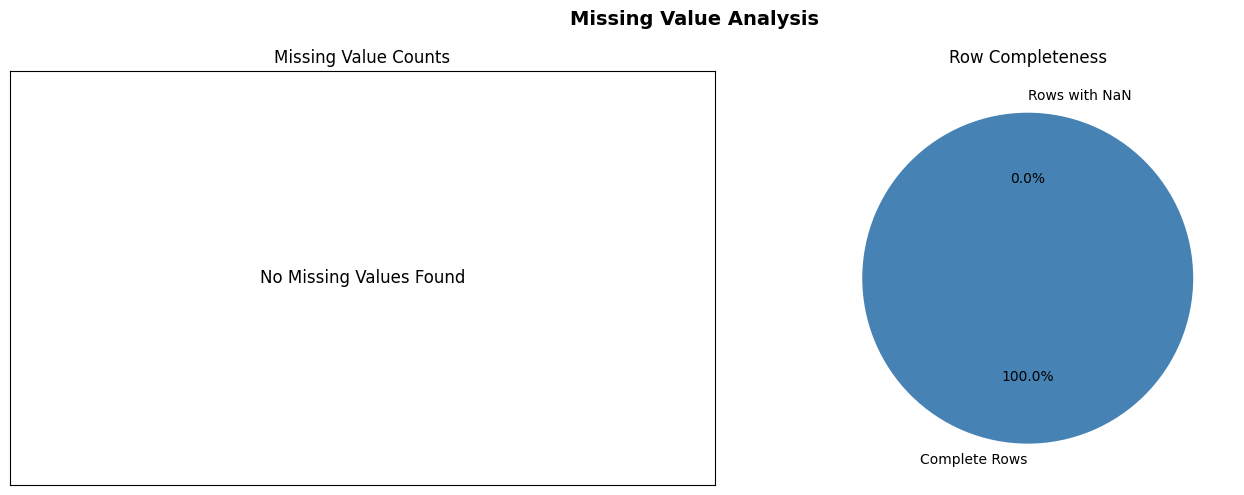


✓ No missing values found in the dataset.


In [4]:
# ── Missing values ────────────────────────────────────────────────────────────
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Missing Value Analysis', fontsize=14, fontweight='bold')

# Missing value bar chart
missing_nonzero = missing[missing > 0]

if len(missing_nonzero) > 0:
    missing_nonzero.plot(
        kind='bar',
        ax=axes[0],
        color='tomato',
        edgecolor='black'
    )
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)
else:
    axes[0].text(
        0.5,
        0.5,
        'No Missing Values Found',
        ha='center',
        va='center',
        fontsize=12,
        transform=axes[0].transAxes
    )
    axes[0].set_xticks([])
    axes[0].set_yticks([])

axes[0].set_title('Missing Value Counts')

# Row completeness pie chart
complete_rows = df_raw.notnull().all(axis=1).sum()
incomplete_rows = df_raw.isnull().any(axis=1).sum()

axes[1].pie(
    [complete_rows, incomplete_rows],
    labels=['Complete Rows', 'Rows with NaN'],
    colors=['steelblue', 'tomato'],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Row Completeness')

plt.tight_layout()
plt.show()

# Print missing value percentages
if len(missing_nonzero) > 0:
    print("\nMissing Value Percentage:")
    print(missing_pct[missing_pct > 0].sort_values(ascending=False))
else:
    print("\n✓ No missing values found in the dataset.")

Exact duplicate rows: 0
Duplicate text rows:  2


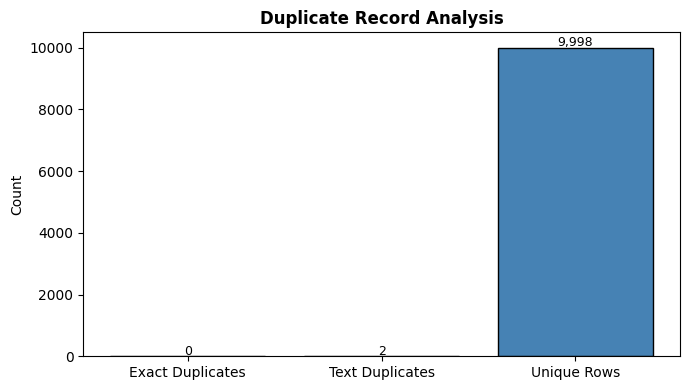

In [5]:
# ── Duplicate analysis ────────────────────────────────────────────────────────
n_exact_dups = df_raw.duplicated().sum()
n_text_dups  = df_raw.duplicated(subset=['text']).sum()
print(f'Exact duplicate rows: {n_exact_dups:,}')
print(f'Duplicate text rows:  {n_text_dups:,}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['Exact Duplicates', 'Text Duplicates', 'Unique Rows'],
       [n_exact_dups, n_text_dups, len(df_raw) - n_text_dups],
       color=['tomato', 'orange', 'steelblue'], edgecolor='black')
ax.set_title('Duplicate Record Analysis', fontweight='bold')
ax.set_ylabel('Count')
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{bar.get_height():,.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

After null removal:       10,000
After duplicate removal:   9,998
After length filter:       9,988


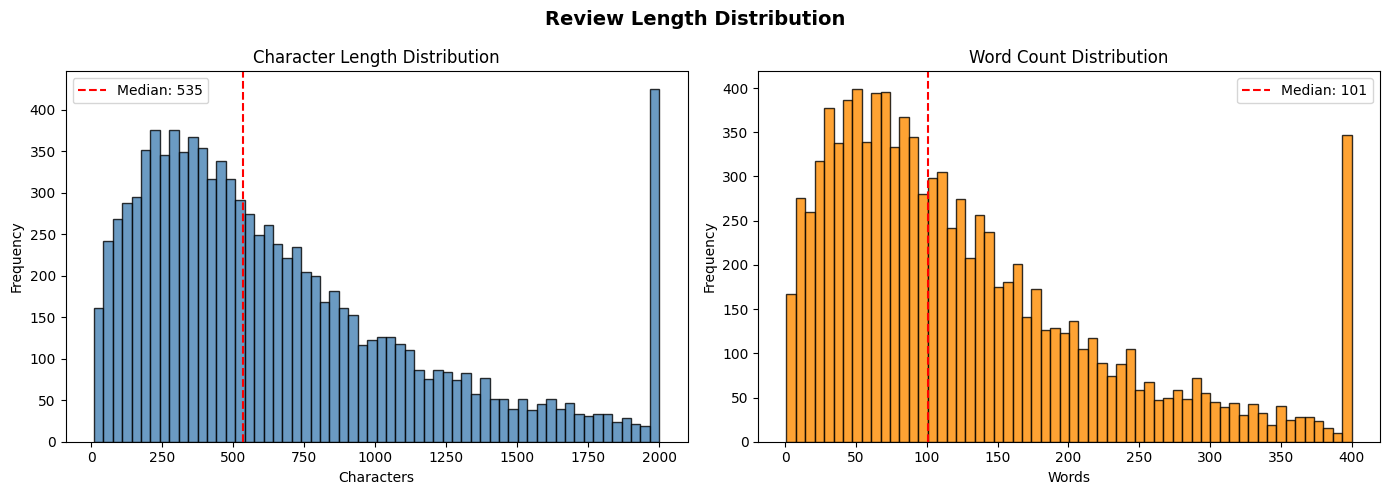

       text_length   word_count
count  9988.000000  9988.000000
mean    701.716159   131.460252
std     608.735977   113.927950
min      10.000000     1.000000
25%     291.000000    54.000000
50%     535.000000   101.000000
75%     919.000000   173.000000
max    4962.000000   950.000000


In [6]:
# ── Text cleaning function ────────────────────────────────────────────────────
def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = unicodedata.normalize('NFKC', text)
    text = re.sub(r'<[^>]+>', ' ', text)          # HTML tags
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)  # URLs
    text = re.sub(r'\S+@\S+', ' ', text)           # emails
    text = re.sub(r'([!?.])\1+', r'\1', text)      # repeated punctuation
    text = re.sub(r'[^\x20-\x7E]', ' ', text)      # non-ASCII
    text = re.sub(r'[^a-zA-Z0-9\s.,!?\'"-]', ' ', text)  # special chars
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

# ── Apply pipeline ────────────────────────────────────────────────────────────
df = df_raw.copy()

# 1. Null removal
df = df.dropna(subset=['text', 'stars'])
print(f'After null removal:      {len(df):>7,}')

# 2. Duplicate removal
df = df.drop_duplicates(subset=['text'])
print(f'After duplicate removal: {len(df):>7,}')

# 3. Stars validation
df['stars'] = pd.to_numeric(df['stars'], errors='coerce')
df = df.dropna(subset=['stars'])
df = df[df['stars'].between(1, 5)]

# 4. Text cleaning
df['text'] = df['text'].astype(str).apply(clean_text)

# 5. Empty/short text removal (min 10 chars)
df = df[df['text'].str.len() >= 10]
print(f'After length filter:     {len(df):>7,}')

# 6. Add text statistics
df['text_length'] = df['text'].str.len()
df['word_count']  = df['text'].str.split().str.len()

# Review length distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Review Length Distribution', fontsize=14, fontweight='bold')

axes[0].hist(df['text_length'].clip(upper=2000), bins=60, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Character Length Distribution')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['text_length'].median(), color='red', linestyle='--', label=f'Median: {df["text_length"].median():.0f}')
axes[0].legend()

axes[1].hist(df['word_count'].clip(upper=400), bins=60, color='darkorange', edgecolor='black', alpha=0.8)
axes[1].set_title('Word Count Distribution')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['word_count'].median(), color='red', linestyle='--', label=f'Median: {df["word_count"].median():.0f}')
axes[1].legend()
plt.tight_layout()
plt.show()
print(df[['text_length', 'word_count']].describe())

## 4. Data Leakage Prevention

In [7]:
LEAKAGE_COLUMNS = ['business_id', 'review_id', 'user_id', 'date', 'cool', 'useful', 'funny', 'type']

print('=== DATA LEAKAGE PREVENTION ===')
print()
leakage_explanations = {
    'business_id': 'Encodes per-business rating bias. Model would memorise businesses, not language.',
    'review_id':   'Unique key with zero predictive signal; can create index leakage.',
    'user_id':     'Encodes per-user rating style (some users always give 1 star). Not a language signal.',
    'date':        'Temporal leakage — if a business improved over time, date correlates with stars.',
    'cool':        'Post-hoc engagement vote — unavailable at inference time.',
    'useful':      'Post-hoc engagement vote — unavailable at inference time.',
    'funny':       'Post-hoc engagement vote — unavailable at inference time.',
    'type':        'Constant column (all = "review"). Zero variance, zero signal.',
}
for col, reason in leakage_explanations.items():
    print(f'  DROP {col:15s}: {reason}')

cols_to_drop = [c for c in LEAKAGE_COLUMNS if c in df.columns]
df = df.drop(columns=cols_to_drop)

print(f'\nColumns after leakage removal: {list(df.columns)}')

# Create labels
def star_to_label(s):
    if s in (1, 2): return 'Negative'
    if s == 3:      return 'Neutral'
    return 'Positive'

def star_to_id(s):
    if s in (1, 2): return 0
    if s == 3:      return 1
    return 2

df['sentiment_label'] = df['stars'].astype(int).apply(star_to_label)
df['label']           = df['stars'].astype(int).apply(star_to_id)

print(f'\nFinal dataframe shape: {df.shape}')
print(df[['text', 'stars', 'sentiment_label', 'label']].head(3))

=== DATA LEAKAGE PREVENTION ===

  DROP business_id    : Encodes per-business rating bias. Model would memorise businesses, not language.
  DROP review_id      : Unique key with zero predictive signal; can create index leakage.
  DROP user_id        : Encodes per-user rating style (some users always give 1 star). Not a language signal.
  DROP date           : Temporal leakage — if a business improved over time, date correlates with stars.
  DROP cool           : Post-hoc engagement vote — unavailable at inference time.
  DROP useful         : Post-hoc engagement vote — unavailable at inference time.
  DROP funny          : Post-hoc engagement vote — unavailable at inference time.
  DROP type           : Constant column (all = "review"). Zero variance, zero signal.

Columns after leakage removal: ['stars', 'text', 'text_length', 'word_count']

Final dataframe shape: (9988, 6)
                                                text  stars sentiment_label  \
0  my wife took me here on my bir

## 5. Exploratory Data Analysis

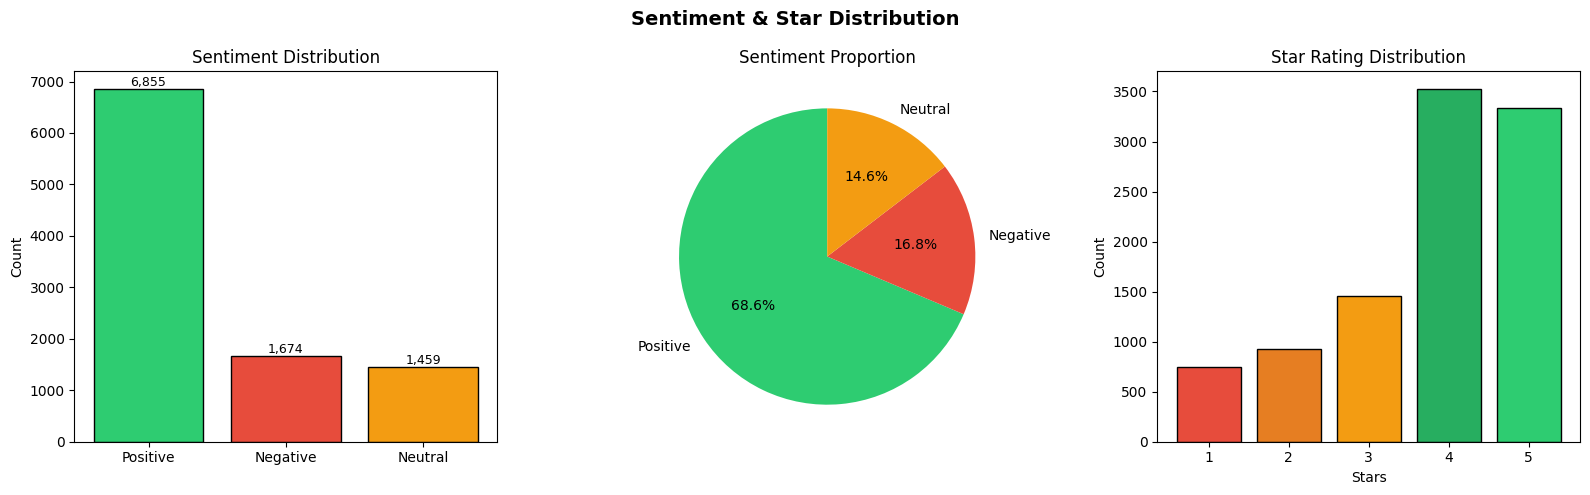

Class imbalance ratio (Pos:Neu:Neg): 6855 : 1459 : 1674


In [8]:
# ── 5.1 Sentiment Distribution ────────────────────────────────────────────────
sent_counts = df['sentiment_label'].value_counts()
colors = {'Positive': '#2ecc71', 'Neutral': '#f39c12', 'Negative': '#e74c3c'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Sentiment & Star Distribution', fontsize=14, fontweight='bold')

# Bar chart
bars = axes[0].bar(sent_counts.index, sent_counts.values,
                   color=[colors[l] for l in sent_counts.index], edgecolor='black')
axes[0].set_title('Sentiment Distribution')
axes[0].set_ylabel('Count')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{bar.get_height():,.0f}', ha='center', fontsize=9)

# Pie chart
axes[1].pie(sent_counts.values, labels=sent_counts.index,
            colors=[colors[l] for l in sent_counts.index],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Sentiment Proportion')

# Star distribution
star_counts = df['stars'].value_counts().sort_index()
axes[2].bar(star_counts.index, star_counts.values,
            color=['#e74c3c', '#e67e22', '#f39c12', '#27ae60', '#2ecc71'],
            edgecolor='black')
axes[2].set_title('Star Rating Distribution')
axes[2].set_xlabel('Stars')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()
print('Class imbalance ratio (Pos:Neu:Neg):', sent_counts['Positive'], ':', sent_counts['Neutral'], ':', sent_counts['Negative'])

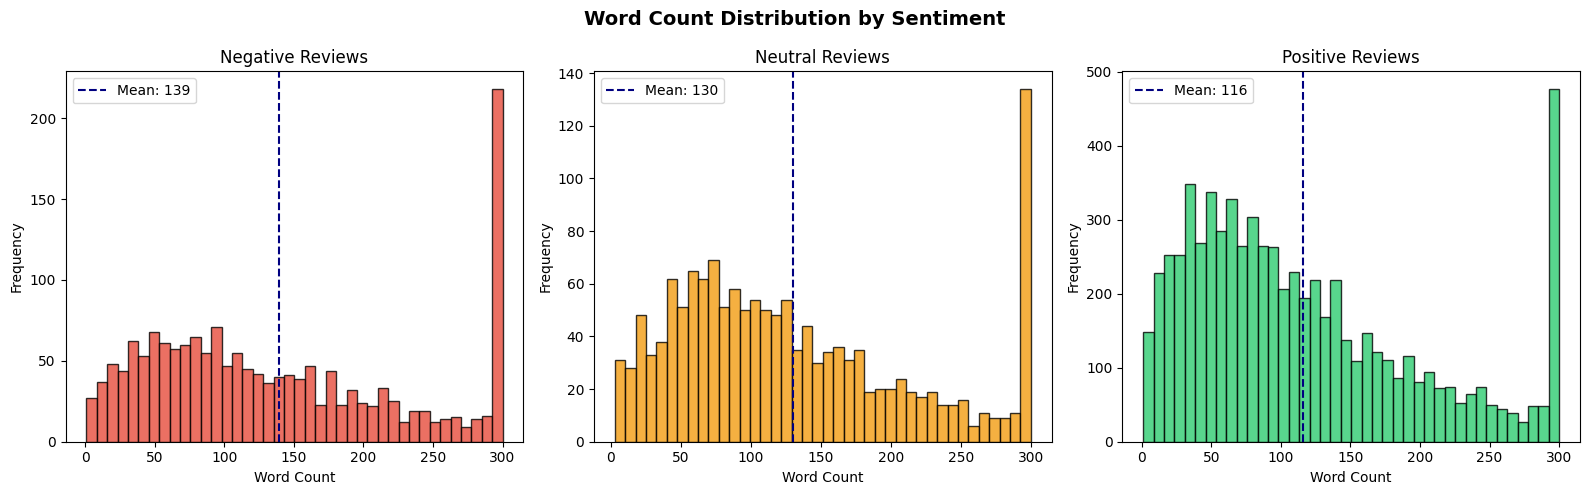

In [9]:
# ── 5.2 Word count distribution by sentiment ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Word Count Distribution by Sentiment', fontsize=14, fontweight='bold')

for ax, sentiment in zip(axes, ['Negative', 'Neutral', 'Positive']):
    data = df[df['sentiment_label'] == sentiment]['word_count'].clip(upper=300)
    ax.hist(data, bins=40, color=colors[sentiment], edgecolor='black', alpha=0.8)
    ax.set_title(f'{sentiment} Reviews')
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Frequency')
    ax.axvline(data.mean(), color='navy', linestyle='--', label=f'Mean: {data.mean():.0f}')
    ax.legend()

plt.tight_layout()
plt.show()

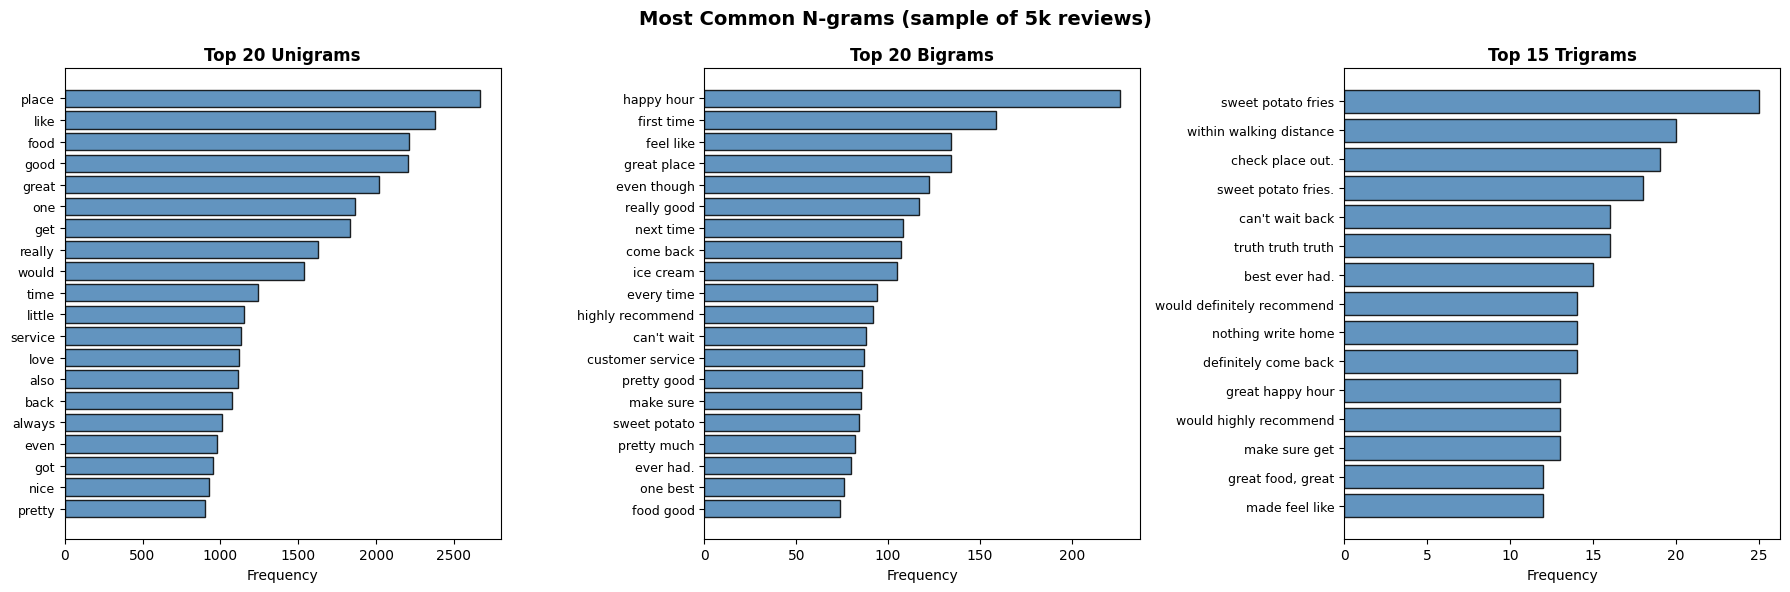

In [10]:
# ── 5.3 N-gram frequency analysis ────────────────────────────────────────────
import nltk
try:
    from nltk.corpus import stopwords
    STOPWORDS = set(stopwords.words('english'))
except LookupError:
    nltk.download('stopwords', quiet=True)
    from nltk.corpus import stopwords
    STOPWORDS = set(stopwords.words('english'))

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)

def get_ngrams(texts: pd.Series, n: int, top_k: int = 20) -> List[Tuple[str, int]]:
    tokens = []
    for text in texts:
        words = [w for w in str(text).split() if w not in STOPWORDS and len(w) > 2]
        if n == 1:
            tokens.extend(words)
        else:
            tokens.extend([' '.join(words[i:i+n]) for i in range(len(words)-n+1)])
    return Counter(tokens).most_common(top_k)

sample_texts = df['text'].sample(min(5000, len(df)), random_state=RANDOM_SEED)

unigrams  = get_ngrams(sample_texts, 1)
bigrams   = get_ngrams(sample_texts, 2)
trigrams  = get_ngrams(sample_texts, 3, top_k=15)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Most Common N-grams (sample of 5k reviews)', fontsize=14, fontweight='bold')

for ax, ngrams, title in zip(axes, [unigrams, bigrams, trigrams],
                              ['Top 20 Unigrams', 'Top 20 Bigrams', 'Top 15 Trigrams']):
    words, counts = zip(*ngrams)
    y_pos = range(len(words))
    ax.barh(y_pos, counts, color='steelblue', edgecolor='black', alpha=0.85)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words, fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Frequency')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [11]:
# ── 5.4 Class imbalance analysis ──────────────────────────────────────────────
total = len(df)
imbalance_df = pd.DataFrame({
    'Class': ['Negative', 'Neutral', 'Positive'],
    'Count': [sent_counts.get('Negative', 0), sent_counts.get('Neutral', 0), sent_counts.get('Positive', 0)],
})
imbalance_df['Percentage'] = (imbalance_df['Count'] / total * 100).round(1)
imbalance_df['Imbalance Ratio'] = (imbalance_df['Count'].max() / imbalance_df['Count']).round(2)

print('=== CLASS IMBALANCE ANALYSIS ===')
print(imbalance_df.to_string(index=False))
print(f'\nDataset total: {total:,}')
print('Strategy: Weighted cross-entropy loss during DistilBERT training.')

=== CLASS IMBALANCE ANALYSIS ===
   Class  Count  Percentage  Imbalance Ratio
Negative   1674        16.8             4.09
 Neutral   1459        14.6             4.70
Positive   6855        68.6             1.00

Dataset total: 9,988
Strategy: Weighted cross-entropy loss during DistilBERT training.


## 6. Traditional NLP Baseline — TF-IDF

Baseline split — Train: 7,990 | Test: 1,998

Fitting TF-IDF with varying max_features ...
  unigram: {1000: 0.7412209290609776, 3000: 0.7544513584790788, 5000: 0.7509388452392047, 10000: 0.7484564881203384, 15000: 0.7432650608452052}
  bigram: {1000: 0.7367401158154295, 3000: 0.7505374525282241, 5000: 0.7507192797151337, 10000: 0.7488150629059497, 15000: 0.7440544327219295}
  trigram: {1000: 0.7368212673163181, 3000: 0.7459840812206903, 5000: 0.7483863885150321, 10000: 0.7482796221437709, 15000: 0.7471168092871604}


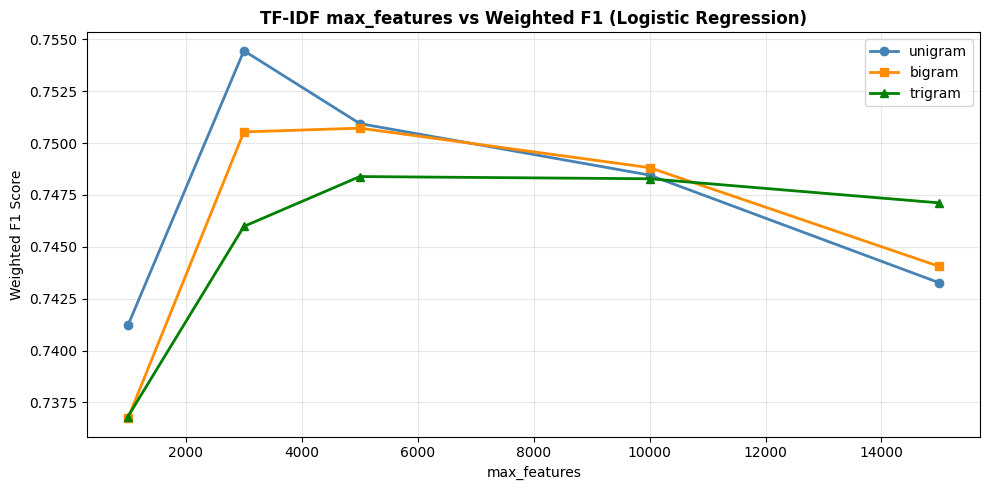

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)

# ── Subsample for baseline speed ──────────────────────────────────────────────
baseline_sample = df.sample(min(20000, len(df)), random_state=RANDOM_SEED)
X_all = baseline_sample['text']
y_all = baseline_sample['label']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_SEED, stratify=y_all
)
print(f'Baseline split — Train: {len(X_train_raw):,} | Test: {len(X_test_raw):,}')

# ── TF-IDF with varying max_features ─────────────────────────────────────────
MAX_FEATURES_OPTIONS = [1000, 3000, 5000, 10000, 15000]
NGRAM_RANGES = {'unigram': (1, 1), 'bigram': (1, 2), 'trigram': (1, 3)}

print('\nFitting TF-IDF with varying max_features ...')
tfidf_results = {}

for ng_name, ng_range in NGRAM_RANGES.items():
    tfidf_results[ng_name] = {}
    for mf in MAX_FEATURES_OPTIONS:
        vec = TfidfVectorizer(ngram_range=ng_range, max_features=mf, sublinear_tf=True)
        X_tr = vec.fit_transform(X_train_raw)
        X_te = vec.transform(X_test_raw)
        lr   = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, C=1.0)
        lr.fit(X_tr, y_train)
        preds = lr.predict(X_te)
        tfidf_results[ng_name][mf] = f1_score(y_test, preds, average='weighted')
    print(f'  {ng_name}: {tfidf_results[ng_name]}')

# ── Plot TF-IDF comparison ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
line_styles = ['-o', '-s', '-^']
color_map   = ['steelblue', 'darkorange', 'green']

for (ng_name, scores), ls, color in zip(tfidf_results.items(), line_styles, color_map):
    ax.plot(list(scores.keys()), list(scores.values()), ls, label=ng_name, color=color, linewidth=2)

ax.set_title('TF-IDF max_features vs Weighted F1 (Logistic Regression)', fontweight='bold')
ax.set_xlabel('max_features')
ax.set_ylabel('Weighted F1 Score')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Chi-Square Feature Selection

  k= 1,000 → F1=0.7294
  k= 3,000 → F1=0.7365
  k= 5,000 → F1=0.7406
  k=10,000 → F1=0.7456


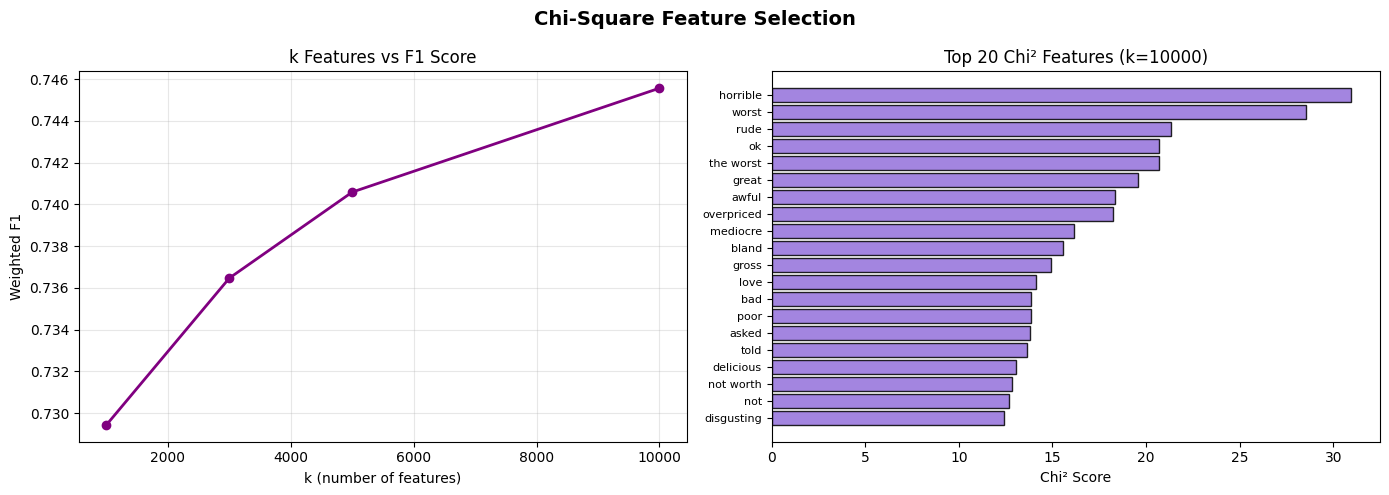

In [13]:
from sklearn.feature_selection import SelectKBest, chi2

K_VALUES = [1000, 3000, 5000, 10000]

# Base TF-IDF with 15k features
base_vec = TfidfVectorizer(ngram_range=(1, 2), max_features=15000, sublinear_tf=True)
X_tr_base = base_vec.fit_transform(X_train_raw)
X_te_base = base_vec.transform(X_test_raw)

chi2_results = {}
for k in K_VALUES:
    sel = SelectKBest(chi2, k=k)
    X_tr_k = sel.fit_transform(X_tr_base, y_train)
    X_te_k = sel.transform(X_te_base)
    lr = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
    lr.fit(X_tr_k, y_train)
    preds = lr.predict(X_te_k)
    chi2_results[k] = f1_score(y_test, preds, average='weighted')
    print(f'  k={k:>6,} → F1={chi2_results[k]:.4f}')

# Visualise top features from best k
best_k = max(chi2_results, key=chi2_results.get)
sel_best = SelectKBest(chi2, k=best_k).fit(X_tr_base, y_train)
feature_names = np.array(base_vec.get_feature_names_out())
top_idx = np.argsort(sel_best.scores_)[-20:][::-1]
top_features = feature_names[top_idx]
top_scores   = sel_best.scores_[top_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Chi-Square Feature Selection', fontsize=14, fontweight='bold')

axes[0].plot(K_VALUES, [chi2_results[k] for k in K_VALUES], '-o', color='purple', linewidth=2)
axes[0].set_title('k Features vs F1 Score')
axes[0].set_xlabel('k (number of features)')
axes[0].set_ylabel('Weighted F1')
axes[0].grid(True, alpha=0.3)

axes[1].barh(range(20), top_scores, color='mediumpurple', edgecolor='black', alpha=0.85)
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(top_features, fontsize=8)
axes[1].set_title(f'Top 20 Chi² Features (k={best_k})')
axes[1].set_xlabel('Chi² Score')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 8. Baseline Models — Logistic Regression, Linear SVM, Multinomial Naive Bayes

In [14]:
# Use best TF-IDF config (bigram, 10k features)
best_vec = TfidfVectorizer(ngram_range=(1, 2), max_features=10000, sublinear_tf=True)
X_tr_best = best_vec.fit_transform(X_train_raw)
X_te_best = best_vec.transform(X_test_raw)

LABEL_NAMES = ['Negative', 'Neutral', 'Positive']

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, C=1.0),
    'Linear SVM':          LinearSVC(max_iter=2000, random_state=RANDOM_SEED, C=1.0),
    'Multinomial NB':      MultinomialNB(alpha=0.1),
}

results_summary = []

for name, model in models.items():
    model.fit(X_tr_best, y_train)
    preds = model.predict(X_te_best)
    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted', zero_division=0)
    rec  = recall_score(y_test, preds, average='weighted', zero_division=0)
    f1   = f1_score(y_test, preds, average='weighted')
    results_summary.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})
    print(f'\n=== {name} ===')
    print(classification_report(y_test, preds, target_names=LABEL_NAMES))

results_df = pd.DataFrame(results_summary)
print('\n=== COMPARISON TABLE ===')
print(results_df.round(4).to_string(index=False))


=== Logistic Regression ===
              precision    recall  f1-score   support

    Negative       0.79      0.56      0.66       335
     Neutral       0.56      0.15      0.24       292
    Positive       0.80      0.98      0.88      1371

    accuracy                           0.79      1998
   macro avg       0.72      0.57      0.59      1998
weighted avg       0.76      0.79      0.75      1998


=== Linear SVM ===
              precision    recall  f1-score   support

    Negative       0.73      0.67      0.70       335
     Neutral       0.43      0.25      0.32       292
    Positive       0.85      0.94      0.89      1371

    accuracy                           0.79      1998
   macro avg       0.67      0.62      0.64      1998
weighted avg       0.77      0.79      0.78      1998


=== Multinomial NB ===
              precision    recall  f1-score   support

    Negative       0.77      0.51      0.61       335
     Neutral       0.55      0.09      0.15       292
  

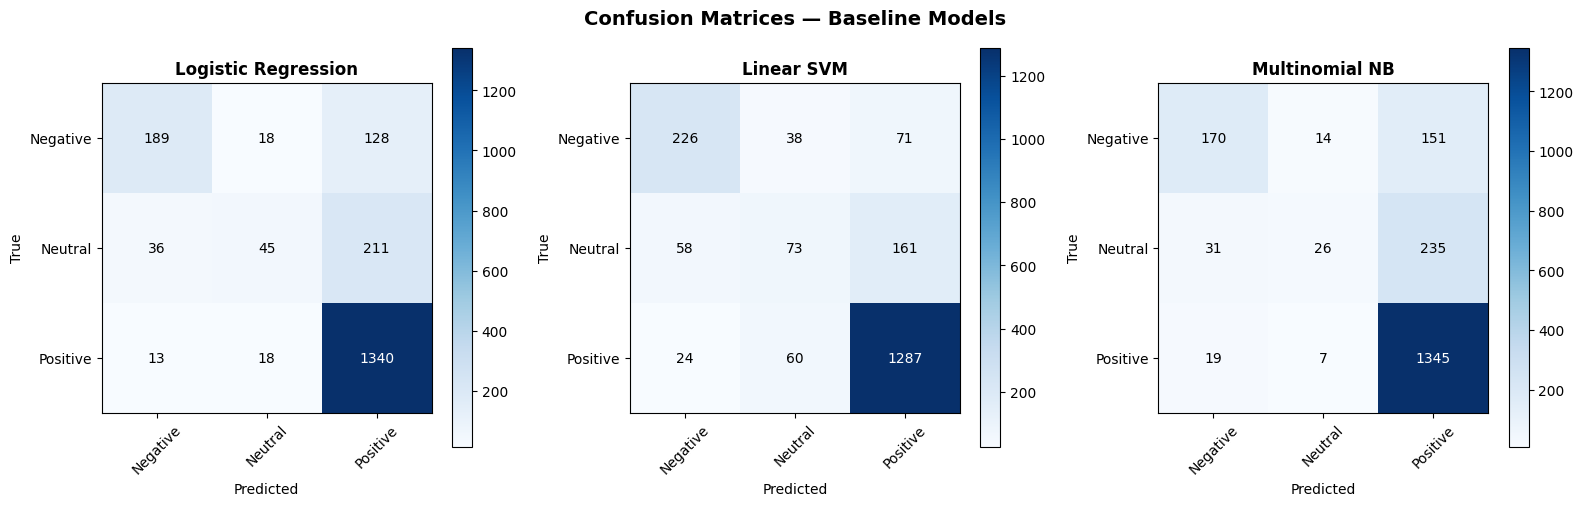

In [15]:
# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrices — Baseline Models', fontsize=14, fontweight='bold')

for ax, (name, model) in zip(axes, models.items()):
    preds = model.predict(X_te_best)
    cm = confusion_matrix(y_test, preds)
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(name, fontweight='bold')
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(LABEL_NAMES, rotation=45); ax.set_yticklabels(LABEL_NAMES)
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
    for i in range(3):
        for j in range(3):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

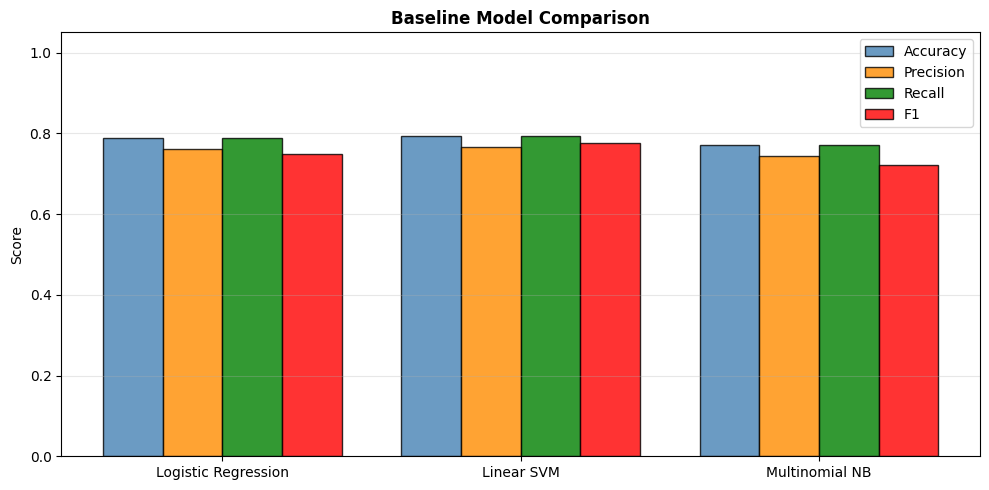

In [16]:
# ── Comparison bar chart ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.2
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
metric_colors = ['steelblue', 'darkorange', 'green', 'red']

for i, (metric, color) in enumerate(zip(metrics, metric_colors)):
    ax.bar(x + i*width, results_df[metric], width, label=metric, color=color, alpha=0.8, edgecolor='black')

ax.set_title('Baseline Model Comparison', fontweight='bold')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(results_df['Model'])
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 9. DistilBERT Sentiment Model

In [ ]:
import torch
from transformers import (
    DistilBertForSequenceClassification,
    DistilBertTokenizerFast,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
)
from datasets import Dataset, DatasetDict
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
USE_FP16 = (DEVICE == 'cuda')
print(f'Device: {DEVICE.upper()} | FP16: {USE_FP16}')

# ── Split ─────────────────────────────────────────────────────────────────────
if SAMPLE_SIZE:
    df_model = df.sample(SAMPLE_SIZE, random_state=RANDOM_SEED)
else:
    df_model = df.copy()

train_df, temp_df = train_test_split(df_model, test_size=0.30, random_state=RANDOM_SEED, stratify=df_model['label'])
val_df,  test_df  = train_test_split(temp_df,  test_size=0.50, random_state=RANDOM_SEED, stratify=temp_df['label'])
print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')

from sklearn.utils import resample

positive = train_df[train_df['label'] == 2]
negative = train_df[train_df['label'] == 0]
neutral  = train_df[train_df['label'] == 1]

print("Before balancing:")
print(train_df['label'].value_counts())

neutral_up = resample(
    neutral,
    replace=True,
    n_samples=len(positive),
    random_state=RANDOM_SEED
)

train_df = pd.concat([
    positive,
    negative,
    neutral_up
])

train_df = train_df.sample(frac=1, random_state=RANDOM_SEED)

print("After balancing:")
print(train_df['label'].value_counts())

# ── Label maps ────────────────────────────────────────────────────────────────
ID2LABEL = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
LABEL2ID = {v: k for k, v in ID2LABEL.items()}

# ── Class weights ─────────────────────────────────────────────────────────────
classes = np.array(sorted(train_df['label'].unique()))
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['label']
)
class_weights = torch.tensor(weights, dtype=torch.float)
print(f'Class weights: {dict(zip([ID2LABEL[c] for c in classes], weights.round(3)))}')

# ── Tokenizer ─────────────────────────────────────────────────────────────────
MODEL_NAME = 'distilbert-base-uncased'
MAX_LENGTH = 192

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

def make_hf_dataset(df_split):
    return Dataset.from_dict({'text': df_split['text'].tolist(), 'label': df_split['label'].tolist()})

raw_datasets = DatasetDict({
    'train':      make_hf_dataset(train_df),
    'validation': make_hf_dataset(val_df),
    'test':       make_hf_dataset(test_df),
})

def tokenise(batch):
    enc = tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH, padding=False)
    enc['labels'] = batch['label']
    return enc

tokenised = raw_datasets.map(tokenise, batched=True, remove_columns=['text', 'label'])
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

2026-07-06 16:35:32,871 [INFO] PyTorch version 2.2.2 available.
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /distilbert-base-uncased/resolve/main/tokenizer_config.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno 8] nodename nor servname provided, or not known)"))'), '(Request ID: 1d6f9d0b-7694-4495-845f-4e0eec8d006f)')' thrown while requesting HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json
2026-07-06 16:35:33,546 [WARNING] '(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /distilbert-base-uncased/resolve/main/tokenizer_config.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno 8] nodename nor servname provided, or not known)"))'), '(Request ID: 1d6f9d0b-7694-4495-845f-4e

Device: CPU | FP16: False
Train: 6,991 | Val: 1,498 | Test: 1,499
Before balancing:
label
2    4798
0    1172
1    1021
Name: count, dtype: int64
After balancing:
label
1    4798
2    4798
0    1172
Name: count, dtype: int64
Class weights: {'Negative': 3.063, 'Neutral': 0.748, 'Positive': 0.748}


'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /distilbert-base-uncased/resolve/main/tokenizer_config.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno 8] nodename nor servname provided, or not known)"))'), '(Request ID: 6ab31d86-9284-4fa7-9c70-d3b2203d7b44)')' thrown while requesting HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json
2026-07-06 16:35:34,555 [WARNING] '(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /distilbert-base-uncased/resolve/main/tokenizer_config.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno 8] nodename nor servname provided, or not known)"))'), '(Request ID: 6ab31d86-9284-4fa7-9c70-d3b2203d7b44)')' thrown while requesting HEAD https://huggingface.

In [ ]:
# ── Weighted loss Trainer ─────────────────────────────────────────────────────
class WeightedLossTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get('labels')
        outputs = model(**inputs)
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights.to(outputs.logits.device))
        loss = loss_fct(outputs.logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy':  accuracy_score(labels, preds),
        'f1':        f1_score(labels, preds, average='weighted'),
        'precision': precision_score(labels, preds, average='weighted', zero_division=0),
        'recall':    recall_score(labels, preds, average='weighted', zero_division=0),
    }

# ── Model ─────────────────────────────────────────────────────────────────────
SENT_MODEL_DIR = os.path.join(MODEL_DIR, 'sentiment')
os.makedirs(SENT_MODEL_DIR, exist_ok=True)

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID
)

training_args = TrainingArguments(
    output_dir=SENT_MODEL_DIR,
    evaluation_strategy='steps',
    save_strategy='steps',
    logging_strategy='steps',
    eval_steps=500,
    save_steps=500,
    logging_steps=100,
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    gradient_accumulation_steps=4,
    gradient_checkpointing=True,
    max_grad_norm=1.0,
    fp16=USE_FP16,
    seed=RANDOM_SEED,
    report_to='none',
    label_names=['labels'],
)

trainer = WeightedLossTrainer(
    class_weights=class_weights,
    model=model,
    args=training_args,
    train_dataset=tokenised['train'],
    eval_dataset=tokenised['validation'],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

print('Starting DistilBERT sentiment training...')
print(f'  Epochs: 5 | Batch: 8 | LR: 3e-5 | Warmup ratio: 0.1')
print(f'  Mixed precision (FP16): {USE_FP16}')
train_output = trainer.train()
print(f'Training complete. Steps: {train_output.global_step}')

'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /distilbert-base-uncased/resolve/main/config.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno 8] nodename nor servname provided, or not known)"))'), '(Request ID: 27158aa8-3f90-4b1e-b88f-14f12c7ad732)')' thrown while requesting HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json
2026-07-06 16:35:57,890 [WARNING] '(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /distilbert-base-uncased/resolve/main/config.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno 8] nodename nor servname provided, or not known)"))'), '(Request ID: 27158aa8-3f90-4b1e-b88f-14f12c7ad732)')' thrown while requesting HEAD https://huggingface.co/distilbert-base-uncased/res

Starting DistilBERT sentiment training...
  Epochs: 5 | Batch: 8 | LR: 3e-5 | Warmup ratio: 0.1
  Mixed precision (FP16): False


  6%|▌         | 100/1680 [04:33<1:10:57,  2.69s/it]

{'loss': 1.0559, 'grad_norm': 4.267029285430908, 'learning_rate': 1.785714285714286e-05, 'epoch': 0.3}


 12%|█▏        | 200/1680 [09:14<1:09:31,  2.82s/it]

...

{'loss': 0.0713, 'grad_norm': 1.795868158340454, 'learning_rate': 7.53968253968254e-06, 'epoch': 3.86}


 83%|████████▎ | 1400/1680 [1:12:10<13:48,  2.96s/it]

{'loss': 0.0394, 'grad_norm': 0.5555624961853027, 'learning_rate': 5.555555555555555e-06, 'epoch': 4.16}


 84%|████████▎ | 1403/1680 [1:12:21<15:54,  3.45s/it]

RuntimeError: MPS backend out of memory (MPS allocated: 5.02 GB, other allocations: 4.02 GB, max allowed: 9.07 GB). Tried to allocate 48.00 MB on private pool. Use PYTORCH_MPS_HIGH_WATERMARK_RATIO=0.0 to disable upper limit for memory allocations (may cause system failure).

## 10. Model Evaluation & Error Analysis

In [ ]:
# ── Test set evaluation ───────────────────────────────────────────────────────
test_results = trainer.evaluate(tokenised['test'])
print('=== TEST SET RESULTS ===')
for k, v in test_results.items():
    if isinstance(v, float):
        print(f'  {k:30s}: {v:.4f}')

# Get raw predictions
pred_output = trainer.predict(tokenised['test'])
logits = pred_output.predictions
probs  = torch.softmax(torch.tensor(logits), dim=-1).numpy()
preds  = np.argmax(logits, axis=-1)
true   = pred_output.label_ids
conf   = probs.max(axis=-1)

print('\n=== CLASSIFICATION REPORT ===')
print(classification_report(true, preds, target_names=LABEL_NAMES))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('DistilBERT Sentiment Model — Evaluation', fontsize=14, fontweight='bold')

cm_arr = confusion_matrix(true, preds)
im = axes[0].imshow(cm_arr, cmap='Blues')
axes[0].set_title('Confusion Matrix')
axes[0].set_xticks(range(3)); axes[0].set_yticks(range(3))
axes[0].set_xticklabels(LABEL_NAMES, rotation=45); axes[0].set_yticklabels(LABEL_NAMES)
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, cm_arr[i, j], ha='center', va='center',
                     color='white' if cm_arr[i, j] > cm_arr.max()/2 else 'black')
plt.colorbar(im, ax=axes[0])

# Confidence distribution
axes[1].hist(conf[preds == true],  bins=30, alpha=0.7, color='steelblue',  label='Correct', edgecolor='black')
axes[1].hist(conf[preds != true],  bins=30, alpha=0.7, color='tomato',     label='Wrong',   edgecolor='black')
axes[1].set_title('Prediction Confidence Distribution')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Count')
axes[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── Error analysis ────────────────────────────────────────────────────────────
test_texts = test_df['text'].reset_index(drop=True)

error_df = pd.DataFrame({
    'text':        test_texts,
    'true_label':  [ID2LABEL[t] for t in true],
    'pred_label':  [ID2LABEL[p] for p in preds],
    'confidence':  conf,
    'correct':     preds == true,
})

top20_correct = error_df[error_df['correct']].nlargest(20, 'confidence')[['text', 'true_label', 'confidence']]
top20_wrong   = error_df[~error_df['correct']].nlargest(20, 'confidence')[['text', 'true_label', 'pred_label', 'confidence']]

print('=== TOP 20 CORRECT PREDICTIONS (highest confidence) ===')
print(top20_correct.to_string(index=False))
print('\n=== TOP 20 INCORRECT PREDICTIONS (highest-confidence mistakes) ===')
print(top20_wrong.to_string(index=False))

# Misclassification study
print('\n=== MISCLASSIFICATION STUDY ===')
mis_matrix = pd.crosstab(
    pd.Series([ID2LABEL[t] for t in true],  name='True'),
    pd.Series([ID2LABEL[p] for p in preds], name='Predicted')
)
print(mis_matrix)

In [ ]:
# ── Save sentiment model ──────────────────────────────────────────────────────
SENT_FINAL_DIR = os.path.join(SENT_MODEL_DIR, 'final')
trainer.save_model(SENT_FINAL_DIR)
tokenizer.save_pretrained(SENT_FINAL_DIR)
print(f'Sentiment model saved to {SENT_FINAL_DIR}')
print('Saved files:', os.listdir(SENT_FINAL_DIR))

## 11. Semantic Analysis

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print('Loading sentence-transformers model: all-MiniLM-L6-v2')
semantic_model = SentenceTransformer('all-MiniLM-L6-v2')

# Use a manageable sample for embedding
sem_sample = df.sample(min(3000, len(df)), random_state=RANDOM_SEED).reset_index(drop=True)
sem_texts  = sem_sample['text'].tolist()

print(f'Computing embeddings for {len(sem_texts):,} reviews...')
embeddings = semantic_model.encode(sem_texts, batch_size=64, show_progress_bar=True, normalize_embeddings=True)
print(f'Embeddings shape: {embeddings.shape}')

In [ ]:
# ── Semantic similarity search ────────────────────────────────────────────────
QUERY = 'the food was cold and tasteless'
query_emb = semantic_model.encode([QUERY], normalize_embeddings=True)
sims = cosine_similarity(query_emb, embeddings)[0]
top_sim_idx = np.argsort(sims)[-5:][::-1]

print(f'=== SEMANTIC SIMILARITY SEARCH ===')
print(f'Query: "{QUERY}"\n')
for i, idx in enumerate(top_sim_idx):
    print(f'{i+1}. [sim={sims[idx]:.3f}] {sem_texts[idx][:120]}...')

# ── Duplicate complaint detection ─────────────────────────────────────────────
THRESHOLD = 0.90
sim_matrix = cosine_similarity(embeddings[:200], embeddings[:200])  # subset for speed
np.fill_diagonal(sim_matrix, 0)
near_dup_pairs = list(zip(*np.where(sim_matrix > THRESHOLD)))
near_dup_pairs = [(i, j) for i, j in near_dup_pairs if i < j]
print(f'\n=== NEAR-DUPLICATE DETECTION (threshold={THRESHOLD}) ===')
print(f'Found {len(near_dup_pairs)} near-duplicate pairs in first 200 reviews.')
if near_dup_pairs:
    i, j = near_dup_pairs[0]
    print(f'\nExample pair (sim={sim_matrix[i,j]:.3f}):')
    print(f'  A: {sem_texts[i][:100]}')
    print(f'  B: {sem_texts[j][:100]}')

## 12. Semantic Clustering

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

N_CLUSTERS = 5
CLUSTER_LABELS = {
    0: 'Food Issues',
    1: 'Service Issues',
    2: 'Staff Issues',
    3: 'Pricing Issues',
    4: 'Cleanliness Issues',
}

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_SEED, n_init=10)
cluster_ids = kmeans.fit_predict(embeddings)
sem_sample['semantic_cluster'] = cluster_ids

print('Cluster distribution:')
print(pd.Series(cluster_ids).value_counts().sort_index())

# ── PCA visualisation ────────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=RANDOM_SEED)
emb_2d_pca = pca.fit_transform(embeddings)

# ── t-SNE visualisation ───────────────────────────────────────────────────────
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_SEED, n_iter=300)
emb_2d_tsne = tsne.fit_transform(embeddings)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Semantic Clustering — KMeans (k=5)', fontsize=14, fontweight='bold')

cluster_colors = plt.cm.tab10(np.linspace(0, 0.9, N_CLUSTERS))

for cid in range(N_CLUSTERS):
    mask = cluster_ids == cid
    for ax, emb_2d, title in zip(axes, [emb_2d_pca, emb_2d_tsne], ['PCA', 't-SNE']):
        ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                   c=[cluster_colors[cid]], label=CLUSTER_LABELS.get(cid, f'Cluster {cid}'),
                   alpha=0.5, s=15)

for ax, title in zip(axes, ['PCA Projection', 't-SNE Projection']):
    ax.set_title(title, fontweight='bold')
    ax.legend(markerscale=2, fontsize=8)
    ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')

plt.tight_layout()
plt.show()

## 13. Aspect-Based Sentiment Analysis

In [ ]:
ASPECT_KEYWORDS = {
    'food':        ['food', 'dish', 'meal', 'taste', 'flavor', 'cooked', 'raw', 'burnt',
                    'delicious', 'bland', 'tasteless', 'fresh', 'stale', 'portion', 'menu',
                    'ingredient', 'pizza', 'burger', 'sushi', 'pasta', 'soup'],
    'service':     ['service', 'wait', 'waiting', 'slow', 'fast', 'quick', 'delivery',
                    'order', 'long wait', 'quick service', 'prompt'],
    'staff':       ['staff', 'waiter', 'waitress', 'server', 'manager', 'employee',
                    'bartender', 'host', 'rude', 'friendly', 'polite', 'helpful',
                    'attentive', 'professional', 'unprofessional'],
    'pricing':     ['price', 'expensive', 'cheap', 'overpriced', 'worth', 'value',
                    'cost', 'affordable', 'pricey', 'bill', 'charge', 'fee'],
    'cleanliness': ['clean', 'dirty', 'filthy', 'hygiene', 'sanitary', 'mess',
                    'spotless', 'gross', 'cockroach', 'bug'],
    'ambience':    ['atmosphere', 'ambience', 'vibe', 'decor', 'music', 'noise',
                    'loud', 'quiet', 'cozy', 'romantic', 'environment', 'setting'],
    'wait_time':   ['wait', 'hour', 'minutes', 'long time', 'forever', 'queue',
                    'reservation', 'seating', 'crowded', 'packed'],
}

NEGATIVE_KEYWORDS = [
    'terrible', 'awful', 'horrible', 'disgusting', 'rude', 'worst', 'never',
    'unacceptable', 'filthy', 'cold', 'raw', 'overpriced', 'waiting', 'slow',
    'ignored', 'wrong', 'mistake', 'disappointing', 'pathetic', 'disgusted',
    'sick', 'hair', 'dirty', 'inedible', 'bland', 'tasteless', 'burnt', 'undercooked',
]

def detect_aspect_sentiment(text: str, neg_present: bool) -> str:
    return 'Negative' if neg_present else 'Positive'

def get_aspects(text: str) -> dict:
    text_lower = text.lower()
    neg_present = any(nkw in text_lower for nkw in NEGATIVE_KEYWORDS)
    result = {}
    for aspect, kws in ASPECT_KEYWORDS.items():
        mentioned = any(kw in text_lower for kw in kws)
        result[f'aspect_{aspect}'] = detect_aspect_sentiment(text, neg_present) if mentioned else 'Not Mentioned'
    return result

# Apply to sample
aspect_sample = df.sample(min(5000, len(df)), random_state=RANDOM_SEED).reset_index(drop=True)
aspect_results = aspect_sample['text'].apply(get_aspects)
aspect_df = pd.DataFrame(aspect_results.tolist())
aspect_sample = pd.concat([aspect_sample, aspect_df], axis=1)

print('Aspect column distribution (sample):')
for col in aspect_df.columns:
    print(f'  {col}: {aspect_sample[col].value_counts().to_dict()}')

# Visualise
fig, ax = plt.subplots(figsize=(12, 6))
aspect_cols = list(aspect_df.columns)
pos_counts = [aspect_sample[c].eq('Positive').sum() for c in aspect_cols]
neg_counts = [aspect_sample[c].eq('Negative').sum() for c in aspect_cols]
x = np.arange(len(aspect_cols))
ax.bar(x - 0.2, pos_counts, 0.4, label='Positive', color='#2ecc71', edgecolor='black')
ax.bar(x + 0.2, neg_counts, 0.4, label='Negative', color='#e74c3c', edgecolor='black')
ax.set_title('Aspect-Based Sentiment Distribution', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([c.replace('aspect_', '') for c in aspect_cols], rotation=30)
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

## 14. Emotion Detection

In [ ]:
EMOTION_KEYWORDS = {
    'Happy':       ['amazing', 'love', 'excellent', 'fantastic', 'perfect', 'wonderful', 'great', 'best'],
    'Satisfied':   ['good', 'nice', 'decent', 'okay', 'solid', 'fine', 'satisfied', 'pleasant'],
    'Frustrated':  ['frustrating', 'annoying', 'irritating', 'tired', 'bothered', 'frustrate'],
    'Disappointed':['disappointed', 'disappointing', 'expected', 'letdown', 'below', 'expected more'],
    'Angry':       ['angry', 'furious', 'outrageous', 'unacceptable', 'horrible', 'terrible', 'outrage'],
}

def detect_emotion(text: str) -> str:
    text_lower = text.lower()
    scores = {e: sum(1 for kw in kws if kw in text_lower) for e, kws in EMOTION_KEYWORDS.items()}
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else 'Satisfied'

df['emotion'] = df['text'].apply(detect_emotion)

emotion_counts = df['emotion'].value_counts()
emotion_colors = ['#f1c40f', '#2ecc71', '#e67e22', '#3498db', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Emotion Detection', fontsize=14, fontweight='bold')

axes[0].bar(emotion_counts.index, emotion_counts.values, color=emotion_colors, edgecolor='black')
axes[0].set_title('Emotion Distribution (Bar)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

axes[1].pie(emotion_counts.values, labels=emotion_counts.index, colors=emotion_colors,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Emotion Distribution (Pie)')
plt.tight_layout()
plt.show()

print(emotion_counts)

## 15. Intent Recognition

In [ ]:
INTENT_KEYWORDS = {
    'Complaint':     ['terrible', 'awful', 'worst', 'never again', 'horrible', 'unacceptable', 'rude'],
    'Suggestion':    ['should', 'could', 'recommend', 'suggest', 'try', 'consider', 'improve', 'wish'],
    'Appreciation':  ['thank', 'appreciate', 'love', 'amazing', 'great', 'wonderful', 'best'],
    'Inquiry':       ['wondering', 'question', 'how', 'what', 'where', 'when', 'does'],
}

def detect_intent(text: str) -> str:
    text_lower = text.lower()
    scores = {i: sum(1 for kw in kws if kw in text_lower) for i, kws in INTENT_KEYWORDS.items()}
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else 'Appreciation'

df['intent'] = df['text'].apply(detect_intent)

intent_counts = df['intent'].value_counts()
intent_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Intent Recognition Analytics', fontsize=14, fontweight='bold')

axes[0].bar(intent_counts.index, intent_counts.values, color=intent_colors, edgecolor='black')
axes[0].set_title('Intent Distribution')
axes[0].set_ylabel('Count')

axes[1].pie(intent_counts.values, labels=intent_counts.index, colors=intent_colors,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Intent Proportion')

plt.tight_layout()
plt.show()
print('Intent analytics:', intent_counts.to_dict())

## 16. Complaint Classification Dataset Creation

In [ ]:
COMPLAINT_LABEL2ID = {
    'Food Quality':           0,
    'Service Delay':          1,
    'Staff Behavior':         2,
    'Pricing Issue':          3,
    'Cleanliness Issue':      4,
    'General Dissatisfaction':5,
}
COMPLAINT_ID2LABEL = {v: k for k, v in COMPLAINT_LABEL2ID.items()}

def categorise_complaint(text: str) -> str:
    t = text.lower()
    food_kws   = ASPECT_KEYWORDS['food']
    svc_kws    = ASPECT_KEYWORDS['service'] + ASPECT_KEYWORDS['wait_time']
    staff_kws  = ASPECT_KEYWORDS['staff']
    price_kws  = ASPECT_KEYWORDS['pricing']
    clean_kws  = ASPECT_KEYWORDS['cleanliness']
    if any(kw in t for kw in food_kws):   return 'Food Quality'
    if any(kw in t for kw in svc_kws):    return 'Service Delay'
    if any(kw in t for kw in staff_kws):  return 'Staff Behavior'
    if any(kw in t for kw in price_kws):  return 'Pricing Issue'
    if any(kw in t for kw in clean_kws):  return 'Cleanliness Issue'
    return 'General Dissatisfaction'

# Filter negative reviews only
complaints_df = df[df['sentiment_label'] == 'Negative'].copy()
complaints_df['complaint_category'] = complaints_df['text'].apply(categorise_complaint)
complaints_df['complaint_label']    = complaints_df['complaint_category'].map(COMPLAINT_LABEL2ID)

print(f'Total complaint records: {len(complaints_df):,}')
print('Category distribution:')
cat_counts = complaints_df['complaint_category'].value_counts()
print(cat_counts)

# Save
complaints_df[['text', 'stars', 'complaint_category', 'complaint_label']].to_csv(COMP_CSV, index=False)
print(f'\nSaved to {COMP_CSV}')

# Visualise
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(cat_counts.index, cat_counts.values, color='steelblue', edgecolor='black', alpha=0.85)
ax.set_title('Complaint Category Distribution', fontweight='bold')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=25)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{bar.get_height():,.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 17. Complaint Classification Model (2nd DistilBERT)

In [ ]:
COMP_MODEL_DIR = os.path.join(MODEL_DIR, 'complaint')
os.makedirs(COMP_MODEL_DIR, exist_ok=True)

comp_train, comp_temp = train_test_split(
    complaints_df, test_size=0.30, random_state=RANDOM_SEED, stratify=complaints_df['complaint_label']
)
comp_val, comp_test = train_test_split(
    comp_temp, test_size=0.50, random_state=RANDOM_SEED, stratify=comp_temp['complaint_label']
)
print(f'Complaint split — Train: {len(comp_train):,} | Val: {len(comp_val):,} | Test: {len(comp_test):,}')

# Class weights
comp_classes = np.array(
    sorted(comp_train['complaint_label'].unique())
)

comp_weights = compute_class_weight(
    class_weight='balanced',
    classes=comp_classes,
    y=comp_train['complaint_label']
)
comp_class_weights = torch.tensor(comp_weights, dtype=torch.float)
print('Complaint class weights:', dict(zip([COMPLAINT_ID2LABEL[c] for c in comp_classes], comp_weights.round(3))))

comp_tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

def make_comp_hf(df_split):
    return Dataset.from_dict({
        'text':  df_split['text'].tolist(),
        'label': df_split['complaint_label'].tolist(),
    })

comp_datasets = DatasetDict({
    'train':      make_comp_hf(comp_train),
    'validation': make_comp_hf(comp_val),
    'test':       make_comp_hf(comp_test),
})

def comp_tokenise(batch):
    enc = comp_tokenizer(batch['text'], truncation=True, max_length=192, padding=False)
    enc['labels'] = batch['label']
    return enc

comp_tok = comp_datasets.map(comp_tokenise, batched=True, remove_columns=['text', 'label'])
comp_collator = DataCollatorWithPadding(tokenizer=comp_tokenizer)

COMP_ID2LABEL = {v: k for k, v in COMPLAINT_LABEL2ID.items()}
comp_model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=6, id2label=COMP_ID2LABEL, label2id=COMPLAINT_LABEL2ID
)

comp_training_args = TrainingArguments(
    output_dir=COMP_MODEL_DIR,
    evaluation_strategy='steps',
    save_strategy='steps',
    logging_strategy='steps',
    eval_steps=200,
    save_steps=200,
    logging_steps=50,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    max_grad_norm=1.0,
    fp16=USE_FP16,
    seed=RANDOM_SEED,
    report_to='none',
    label_names=['labels'],
)

COMP_LABEL_NAMES = [COMP_ID2LABEL[i] for i in range(6)]

comp_trainer = WeightedLossTrainer(
    class_weights=comp_class_weights,
    model=comp_model,
    args=comp_training_args,
    train_dataset=comp_tok['train'],
    eval_dataset=comp_tok['validation'],
    tokenizer=comp_tokenizer,
    data_collator=comp_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print('Starting complaint classification training...')
comp_trainer.train()
comp_results = comp_trainer.evaluate(comp_tok['test'])
print('=== COMPLAINT MODEL TEST RESULTS ===')
for k, v in comp_results.items():
    if isinstance(v, float):
        print(f'  {k:30s}: {v:.4f}')

# Predictions & classification report
comp_pred_out = comp_trainer.predict(comp_tok['test'])
comp_preds = np.argmax(comp_pred_out.predictions, axis=-1)
comp_true  = comp_pred_out.label_ids

print('\n=== COMPLAINT CLASSIFICATION REPORT ===')
print(classification_report(comp_true, comp_preds, target_names=COMP_LABEL_NAMES))

# Confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
cm_comp = confusion_matrix(comp_true, comp_preds)
im = ax.imshow(cm_comp, cmap='Blues')
ax.set_title('Complaint Classification Confusion Matrix', fontweight='bold')
ax.set_xticks(range(6)); ax.set_yticks(range(6))
ax.set_xticklabels(COMP_LABEL_NAMES, rotation=40, ha='right')
ax.set_yticklabels(COMP_LABEL_NAMES)
ax.set_ylabel('True'); ax.set_xlabel('Predicted')
for i in range(6):
    for j in range(6):
        ax.text(j, i, cm_comp[i, j], ha='center', va='center',
                color='white' if cm_comp[i, j] > cm_comp.max()/2 else 'black')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# Save complaint model
COMP_FINAL_DIR = os.path.join(COMP_MODEL_DIR, 'final')
comp_trainer.save_model(COMP_FINAL_DIR)
comp_tokenizer.save_pretrained(COMP_FINAL_DIR)
print(f'Complaint model saved to {COMP_FINAL_DIR}')

## 18. Topic Modeling — LDA

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

N_TOPICS = 6
TOPIC_LABELS = [
    'Food & Dining',
    'Service Quality',
    'Staff & Experience',
    'Pricing & Value',
    'Ambience & Atmosphere',
    'General Feedback',
]

lda_sample = df['text'].sample(min(10000, len(df)), random_state=RANDOM_SEED)

count_vec = CountVectorizer(
    max_features=5000,
    stop_words='english',
    max_df=0.95,
    min_df=5,
)
dtm = count_vec.fit_transform(lda_sample)

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    max_iter=20,
    random_state=RANDOM_SEED,
    learning_method='online',
)
lda.fit(dtm)

# Top words per topic
vocab = count_vec.get_feature_names_out()
print('=== LDA TOPICS ===')
for topic_id, topic in enumerate(lda.components_):
    top_words = [vocab[i] for i in topic.argsort()[-10:][::-1]]
    print(f'Topic {topic_id} [{TOPIC_LABELS[topic_id]}]: {" | ".join(top_words)}')

# Assign topics to full dataset
full_dtm = count_vec.transform(df['text'])
topic_dist = lda.transform(full_dtm)
df['topic_id']    = topic_dist.argmax(axis=1)
df['topic_label'] = df['topic_id'].apply(lambda x: TOPIC_LABELS[x])

# Topic distribution chart
topic_counts = df['topic_label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('LDA Topic Distribution', fontsize=14, fontweight='bold')

axes[0].barh(topic_counts.index, topic_counts.values, color='teal', edgecolor='black', alpha=0.85)
axes[0].set_title('Topic Counts')
axes[0].set_xlabel('Count')

# Top words grid
axes[1].axis('off')
table_data = []
for tid, topic in enumerate(lda.components_):
    top_words = ', '.join([vocab[i] for i in topic.argsort()[-5:][::-1]])
    table_data.append([TOPIC_LABELS[tid], top_words])

tbl = axes[1].table(cellText=table_data, colLabels=['Topic', 'Top Words'],
                     loc='center', cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.8)
axes[1].set_title('Top 5 Words per Topic')

plt.tight_layout()
plt.show()

## 19. Complaint Severity Scoring

In [ ]:
def compute_severity(row) -> str:
    """
    Multi-signal severity scoring:
    1. Sentiment (negative → higher base score)
    2. Complaint category risk weight
    3. Negative keyword density
    4. Review length (more issues mentioned → longer)
    """
    score = 0
    text_lower = str(row.get('text', '')).lower()
    sentiment  = row.get('sentiment_label', 'Neutral')
    category   = row.get('complaint_category', 'General Dissatisfaction')
    word_count = row.get('word_count', len(text_lower.split()))

    # Signal 1: Sentiment
    if sentiment == 'Negative':
        score += 2
    elif sentiment == 'Neutral':
        score += 1

    # Signal 2: Category risk
    high_risk   = {'Staff Behavior', 'Cleanliness Issue'}
    medium_risk = {'Service Delay', 'Food Quality'}
    if category in high_risk:   score += 3
    elif category in medium_risk: score += 2
    else: score += 1

    # Signal 3: Negative keyword density
    neg_hits = sum(1 for kw in NEGATIVE_KEYWORDS if kw in text_lower)
    score += min(neg_hits, 3)

    # Signal 4: Length (longer = more issues mentioned)
    if word_count > 200:   score += 2
    elif word_count > 100: score += 1

    if score >= 8:   return 'Critical'
    elif score >= 5: return 'High'
    elif score >= 3: return 'Medium'
    return 'Low'

# We need complaint_category on the full df (use rule-based for Positive/Neutral)
df['complaint_category'] = df.apply(
    lambda r: categorise_complaint(r['text']) if r['sentiment_label'] == 'Negative' else 'N/A',
    axis=1
)
df['complaint_severity'] = df.apply(compute_severity, axis=1)

sev_counts = df['complaint_severity'].value_counts()
sev_colors = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e67e22', 'Critical': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Complaint Severity Distribution', fontsize=14, fontweight='bold')

level_order = ['Low', 'Medium', 'High', 'Critical']
ordered = sev_counts.reindex(level_order, fill_value=0)

axes[0].bar(ordered.index, ordered.values, color=[sev_colors[l] for l in ordered.index], edgecolor='black')
axes[0].set_title('Severity Level Counts')
axes[0].set_ylabel('Count')

axes[1].pie(ordered.values, labels=ordered.index, colors=[sev_colors[l] for l in ordered.index],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Severity Proportion')

plt.tight_layout()
plt.show()
print(sev_counts)

## 20. Final Dataset Assembly

In [ ]:
# Build full enriched dataset with all required columns
enriched = df.copy()

# Add sentiment_score (use confidence proxy from star distance from 3)
def stars_to_score(stars):
    return round(abs(stars - 3) / 2, 2)
enriched['sentiment_score'] = enriched['stars'].apply(stars_to_score)

# Add aspects (already computed, re-apply to full df)
print('Computing aspect sentiments on full dataset...')
aspect_full = enriched['text'].apply(get_aspects)
aspect_full_df = pd.DataFrame(aspect_full.tolist(), index=enriched.index)

for col in aspect_full_df.columns:
    enriched[col] = aspect_full_df[col]

# Add semantic_cluster (assign cluster to full df using KMeans model)
print('Assigning semantic clusters to full dataset...')
full_embeddings = semantic_model.encode(
    enriched['text'].tolist(), batch_size=128, show_progress_bar=True, normalize_embeddings=True
)
enriched['semantic_cluster'] = kmeans.predict(full_embeddings)

FINAL_COLUMNS = [
    'text', 'stars', 'sentiment_label', 'sentiment_score',
    'emotion', 'intent', 'complaint_category', 'complaint_severity',
    'semantic_cluster', 'topic_label',
    'aspect_food', 'aspect_service', 'aspect_staff', 'aspect_pricing',
    'aspect_cleanliness', 'aspect_ambience', 'aspect_wait_time',
]

final_df = enriched[FINAL_COLUMNS].copy()
final_df.to_csv(FINAL_CSV, index=False)

print(f'\nFinal enriched dataset shape: {final_df.shape}')
print(f'Saved to {FINAL_CSV}')
final_df.head(3)

In [ ]:
# ── Dataset summary dashboard ─────────────────────────────────────────────────
print('=== FINAL ENRICHED DATASET SUMMARY ===')
print(f'Total reviews: {len(final_df):,}')
print(f'Columns: {list(final_df.columns)}')
print()
print('Sentiment distribution:')
print(final_df['sentiment_label'].value_counts())
print('\nEmotion distribution:')
print(final_df['emotion'].value_counts())
print('\nIntent distribution:')
print(final_df['intent'].value_counts())
print('\nSeverity distribution:')
print(final_df['complaint_severity'].value_counts())
print('\nTopic distribution:')
print(final_df['topic_label'].value_counts())

## 21. Model Export & Inference Pipeline

In [ ]:
# ── Verify saved model files ──────────────────────────────────────────────────
print('=== MODEL EXPORT VERIFICATION ===')
for model_name, model_dir in [('Sentiment', SENT_FINAL_DIR), ('Complaint', COMP_FINAL_DIR)]:
    if os.path.exists(model_dir):
        files = os.listdir(model_dir)
        print(f'{model_name} model files: {files}')
    else:
        print(f'{model_name} model directory not found: {model_dir}')

In [ ]:
# ── Production inference pipeline ─────────────────────────────────────────────
from transformers import pipeline as hf_pipeline

def predict_sentiment(text: str, sent_pipe) -> dict:
    """
    Production-ready sentiment predictor.
    Returns: {"sentiment": "Positive", "confidence": 0.98}
    """
    if not text or not text.strip():
        return {'sentiment': 'Neutral', 'confidence': 0.0}
    results = sent_pipe(text[:512])[0]
    best = max(results, key=lambda x: x['score'])
    return {'sentiment': best['label'], 'confidence': round(best['score'], 4)}

def predict_complaint(text: str, comp_pipe) -> dict:
    """
    Production-ready complaint classifier.
    Returns: {"category": "Service Delay", "confidence": 0.94}
    """
    if not text or not text.strip():
        return {'category': 'General Dissatisfaction', 'confidence': 0.0}
    results = comp_pipe(text[:512])[0]
    best = max(results, key=lambda x: x['score'])
    return {'category': best['label'], 'confidence': round(best['score'], 4)}

# Load inference pipelines
if os.path.exists(SENT_FINAL_DIR):
    infer_sent_pipe = hf_pipeline(
        'text-classification',
        model=SENT_FINAL_DIR,
        tokenizer=SENT_FINAL_DIR,
        device=0 if torch.cuda.is_available() else -1,
        return_all_scores=True,
    )
    print('Sentiment inference pipeline loaded.')
else:
    infer_sent_pipe = None
    print('Sentiment model not found — train first.')

if os.path.exists(COMP_FINAL_DIR):
    infer_comp_pipe = hf_pipeline(
        'text-classification',
        model=COMP_FINAL_DIR,
        tokenizer=COMP_FINAL_DIR,
        device=0 if torch.cuda.is_available() else -1,
        return_all_scores=True,
    )
    print('Complaint inference pipeline loaded.')
else:
    infer_comp_pipe = None
    print('Complaint model not found — train first.')

In [ ]:
# ── Inference demo ────────────────────────────────────────────────────────────
test_reviews = [
    'The food was absolutely terrible. Cold, tasteless, and the waiter was incredibly rude!',
    'Great experience! The staff were super friendly and the pasta was delicious.',
    'It was okay, nothing special. Service was a bit slow but food was decent.',
    'I waited over an hour for my food. Completely unacceptable. Never coming back.',
    'Loved the atmosphere! Great cocktails and the price was very reasonable.',
]

print('=== INFERENCE PIPELINE DEMO ===\n')
for review in test_reviews:
    print(f'Review: {review[:80]}...')
    
    if infer_sent_pipe:
        sent_result = predict_sentiment(review, infer_sent_pipe)
        print(f'  Sentiment: {sent_result}')
        
        if sent_result['sentiment'] == 'Negative' and infer_comp_pipe:
            comp_result = predict_complaint(review, infer_comp_pipe)
            print(f'  Complaint: {comp_result}')
    
    print(f'  Emotion:   {detect_emotion(review)}')
    print(f'  Intent:    {detect_intent(review)}')
    aspects = get_aspects(review)
    mentioned = {k: v for k, v in aspects.items() if v != 'Not Mentioned'}
    print(f'  Aspects:   {mentioned}')
    print()

In [ ]:
# ── Final pipeline summary ────────────────────────────────────────────────────
print('=======================================================')
print('         GenReview AI — PIPELINE COMPLETE')
print('=======================================================')
print()
print(f'  Dataset rows:               {len(final_df):>10,}')
print(f'  Final columns:              {len(final_df.columns):>10}')
print(f'  Sentiment model:            {SENT_FINAL_DIR}')
print(f'  Complaint model:            {COMP_FINAL_DIR}')
print(f'  Final CSV:                  {FINAL_CSV}')
print(f'  Complaints CSV:             {COMP_CSV}')
print()
print('  API: uvicorn app:app --host 0.0.0.0 --port 8000')
print('       POST /predict-sentiment')
print('       POST /predict-complaint')
print('       POST /predict-full')
print('=======================================================')